In [1]:
!pip install xgboost

>>> PREPARANDO AMBIENTE DE TREINAMENTO <<<


⚠️ Usando amostra de 20.0% dos dados.
✅ Dados Carregados: 65242 linhas x 89 colunas
⚠️ Removendo classes raras para evitar crash no stratify: ['Web Attack - Sql Injection', 'Heartbleed']

🔧 Separando Features (X) e Alvo (y)...
🔢 Codificando Labels (Benign -> 0, DDoS -> 1, ...)


📊 Treino: 52192 amostras | Teste: 13048 amostras

🚀 INICIANDO TREINAMENTO COM OTIMIZAÇÃO (RandomizedSearchCV)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


[CV] END gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=200; total time=  12.2s


[CV] END gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=200; total time=  10.9s


...

[CV] END gamma=1.0, learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=200; total time=  12.5s


[CV] END gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100; total time=   6.0s


[CV] END gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100; total time=   5.5s


[CV] END gamma=1.0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100; total time=   5.2s


✅ OTIMIZAÇÃO CONCLUÍDA! Melhores parâmetros: {'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1.0}
💾 Cérebro salvo em: ../models\modelo_xgboost.json

📝 APLICANDO A PROVA (PREDIÇÃO NO TESTE)...

📋 RELATÓRIO DE DESEMPENHO:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00      9083
                  Benign       0.99      1.00      1.00       384
                     Bot       1.00      0.67      0.80         6
                    DDoS       1.00      1.00      1.00       526
           DoS GoldenEye       1.00      0.97      0.99        35
                DoS Hulk       1.00      1.00      1.00       917
        DoS Slowhttptest       0.95      0.95      0.95        20
           DoS slowloris       0.95      0.91      0.93        23
               DrDoS_DNS       0.31      0.25      0.28        16
              DrDoS_LDAP       0.50      0.40      0.44         5
         

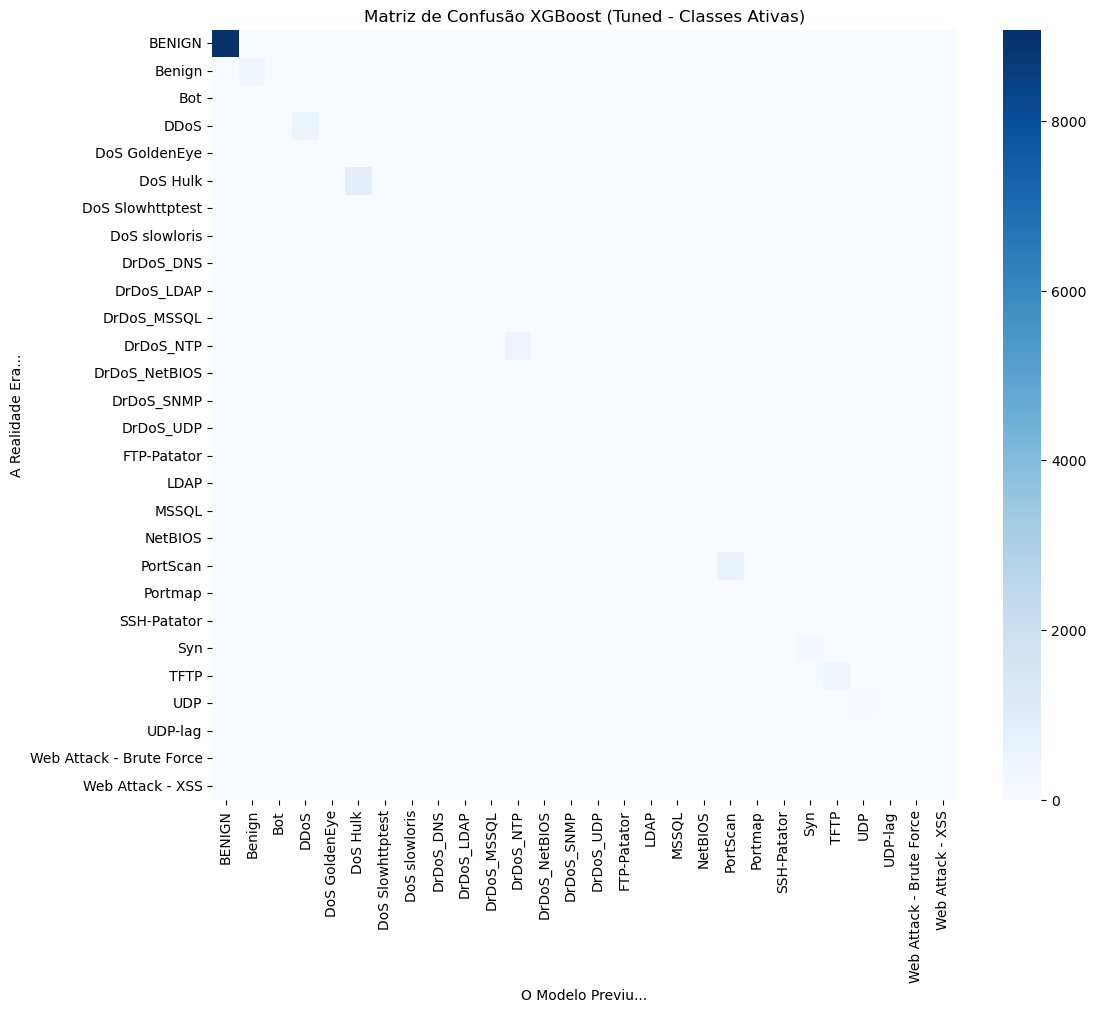

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import joblib # Para salvar o codificador de labels
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. CONFIGURAÇÕES
# =============================================================================
ARQUIVO_LIMPO = r"../data/processed\dataset_limpo.parquet"
MODELO_SAIDA = r"../models\modelo_xgboost.json"
LABEL_ENCODER_FILE = r"../models\label_encoder.joblib"

# Amostra reduzida para 20% para evitar estouro de RAM e agilizar
AMOSTRA_TREINO = 0.2 

print(">>> PREPARANDO AMBIENTE DE TREINAMENTO <<<")

try:
    # Tenta carregar o dataset no caminho novo organizado
    df = pd.read_parquet(ARQUIVO_LIMPO)
except FileNotFoundError:
    # Fallback para o caso de não ter movido
    ARQUIVO_LIMPO = r"../data/processed\dataset_limpo.parquet"
    MODELO_SAIDA = r"../models\modelo_xgboost.json"
    LABEL_ENCODER_FILE = r"../models\label_encoder.joblib"
    df = pd.read_parquet(ARQUIVO_LIMPO)

if AMOSTRA_TREINO < 1.0:
    df = df.sample(frac=AMOSTRA_TREINO, random_state=42)
    print(f"⚠️ Usando amostra de {AMOSTRA_TREINO*100}% dos dados.")

print(f"✅ Dados Carregados: {df.shape[0]} linhas x {df.shape[1]} colunas")

class_counts = df["Label"].value_counts()
invalid_classes = class_counts[class_counts < 2].index
if len(invalid_classes) > 0:
    print(f"⚠️ Removendo classes raras para evitar crash no stratify: {list(invalid_classes)}")
    df = df[~df["Label"].isin(invalid_classes)]

# =============================================================================
# 2. PREPARAÇÃO (X e y)
# =============================================================================
print("\n🔧 Separando Features (X) e Alvo (y)...")

y = df['Label']
X = df.drop(columns=['Label'])

del df
gc.collect()

print("🔢 Codificando Labels (Benign -> 0, DDoS -> 1, ...)")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
joblib.dump(le, LABEL_ENCODER_FILE)

# Divisão com stratify=y_encoded para garantir proporções precisas
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"📊 Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

# =============================================================================
# 3. TREINAMENTO (RandomizedSearchCV - Foco em Recall / Falsos Negativos)
# =============================================================================
print("\n🚀 INICIANDO TREINAMENTO COM OTIMIZAÇÃO (RandomizedSearchCV)...")

base_model = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(le.classes_), 
    n_jobs=-1,
    tree_method='hist'
)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'gamma': [0.5, 1.0],
    'min_child_weight': [1, 3]
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=5,
    scoring='recall_macro', # Foco em Recall (reduzir Falsos Negativos)
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1 # Evitar duplicacao de threads com XGBoost
)

random_search.fit(X_train, y_train)

model = random_search.best_estimator_
print(f"✅ OTIMIZAÇÃO CONCLUÍDA! Melhores parâmetros: {random_search.best_params_}")

model.save_model(MODELO_SAIDA)
print(f"💾 Cérebro salvo em: {MODELO_SAIDA}")

# =============================================================================
# 4. AVALIAÇÃO OTIMIZADA
# =============================================================================
print("\n📝 APLICANDO A PROVA (PREDIÇÃO NO TESTE)...")
y_pred = model.predict(X_test)

print("\n📋 RELATÓRIO DE DESEMPENHO:")
labels_presentes = np.unique(np.concatenate((y_test, y_pred)))
nomes_presentes = [le.classes_[i] for i in labels_presentes]
print(classification_report(y_test, y_pred, labels=labels_presentes, target_names=nomes_presentes))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred, labels=labels_presentes)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=nomes_presentes, yticklabels=nomes_presentes)
plt.title("Matriz de Confusão XGBoost (Tuned - Classes Ativas)")
plt.xlabel("O Modelo Previu...")
plt.ylabel("A Realidade Era...")
plt.xticks(rotation=90)
plt.savefig("matriz_xgb_tuned.png")
plt.show()


>>> GERANDO RELATÓRIO CORRIGIDO <<<
📊 Classes Totais no Projeto: 28
📉 Classes Presentes no Teste: 28

📋 RELATÓRIO DE DESEMPENHO:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00      9083
                  Benign       0.99      1.00      1.00       384
                     Bot       1.00      0.67      0.80         6
                    DDoS       1.00      1.00      1.00       526
           DoS GoldenEye       1.00      0.97      0.99        35
                DoS Hulk       1.00      1.00      1.00       917
        DoS Slowhttptest       0.95      0.95      0.95        20
           DoS slowloris       0.95      0.91      0.93        23
               DrDoS_DNS       0.31      0.25      0.28        16
              DrDoS_LDAP       0.50      0.40      0.44         5
             DrDoS_MSSQL       0.39      0.57      0.46        23
               DrDoS_NTP       0.99      1.00      0.99       496
           D

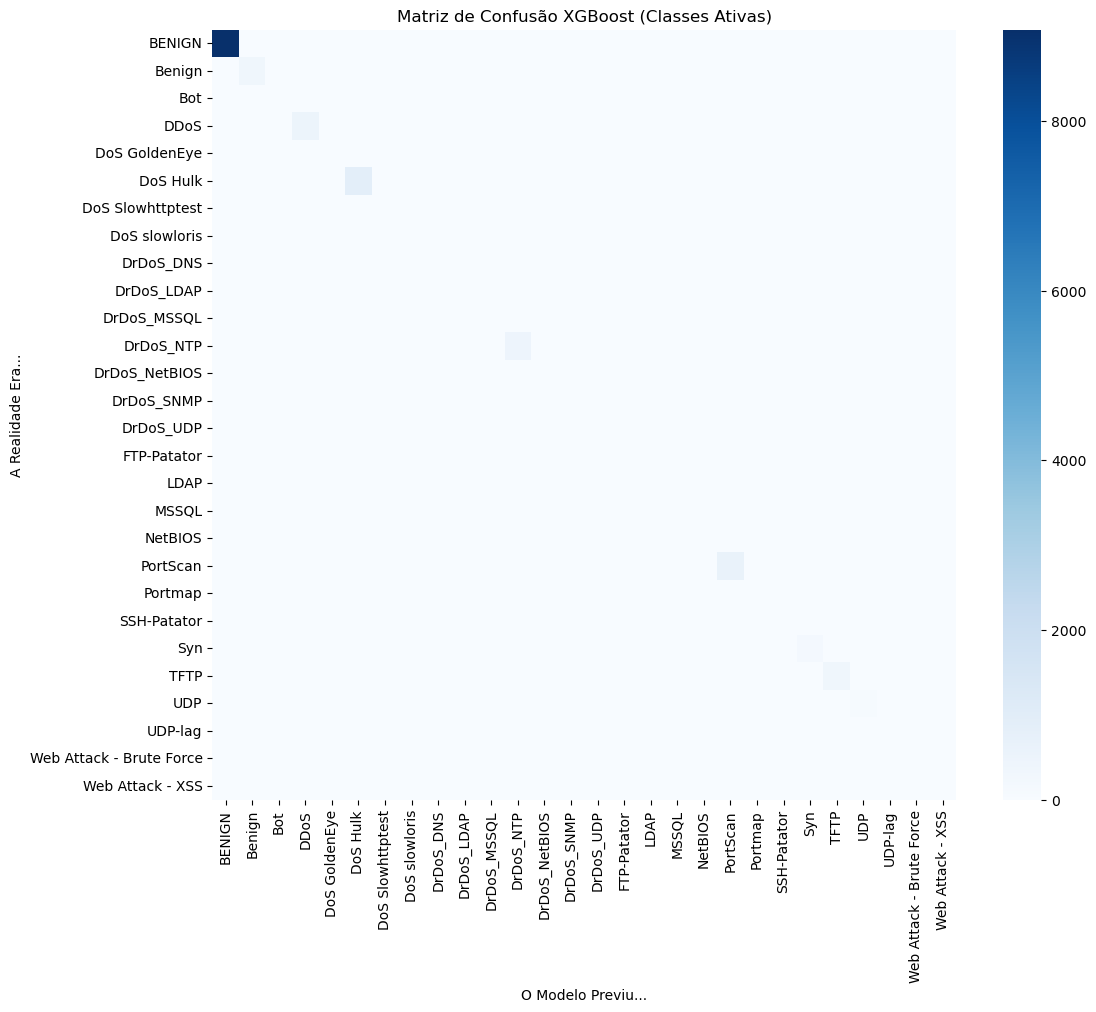

In [3]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(">>> GERANDO RELATÓRIO CORRIGIDO <<<")

# 1. Identifica quais classes realmente existem nos dados de Teste
# (Ignora aquela classe raríssima que só caiu no Treino)
labels_presentes = np.unique(np.concatenate((y_test, y_pred)))
nomes_presentes = [le.classes_[i] for i in labels_presentes]

print(f"📊 Classes Totais no Projeto: {len(le.classes_)}")
print(f"📉 Classes Presentes no Teste: {len(labels_presentes)}")

# 2. Gera o relatório filtrando apenas o que existe
print("\n📋 RELATÓRIO DE DESEMPENHO:")
print(classification_report(y_test, y_pred, labels=labels_presentes, target_names=nomes_presentes))

# 3. Matriz de Confusão (Replotando)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred, labels=labels_presentes)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=nomes_presentes, yticklabels=nomes_presentes)
plt.title("Matriz de Confusão XGBoost (Classes Ativas)")
plt.xlabel("O Modelo Previu...")
plt.ylabel("A Realidade Era...")
plt.xticks(rotation=90)
plt.show()

>>> AVALIAÇÃO BINÁRIA (DEFESA CIBERNÉTICA) <<<
🛡️ Acurácia de Defesa (Binária): 99.90%
🎯 Precisão (Se bloqueou, era ataque?): 99.82%
🕵️ Recall (Pegou todos os ataques?): 99.85%


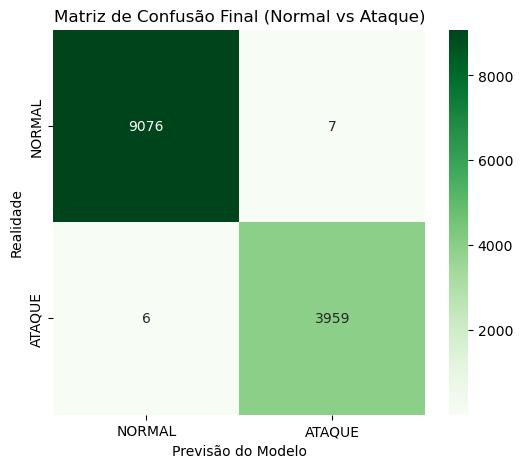

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print(">>> AVALIAÇÃO BINÁRIA (DEFESA CIBERNÉTICA) <<<")

# 1. Converter números de volta para nomes para podermos agrupar
nomes_reais = le.inverse_transform(y_test)
nomes_preditos = le.inverse_transform(y_pred)

# 2. Transformar tudo que NÃO for 'BENIGN' em 'ATAQUE'
binario_real = ['NORMAL' if x == 'BENIGN' else 'ATAQUE' for x in nomes_reais]
binario_pred = ['NORMAL' if x == 'BENIGN' else 'ATAQUE' for x in nomes_preditos]

# 3. Calcular métricas
acuracia_bin = accuracy_score(binario_real, binario_pred)
precisao_bin = precision_score(binario_real, binario_pred, pos_label='ATAQUE')
recall_bin = recall_score(binario_real, binario_pred, pos_label='ATAQUE')

print(f"🛡️ Acurácia de Defesa (Binária): {acuracia_bin*100:.2f}%")
print(f"🎯 Precisão (Se bloqueou, era ataque?): {precisao_bin*100:.2f}%")
print(f"🕵️ Recall (Pegou todos os ataques?): {recall_bin*100:.2f}%")

# Matriz de Confusão Simplificada
cm_bin = confusion_matrix(binario_real, binario_pred, labels=['NORMAL', 'ATAQUE'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Greens', xticklabels=['NORMAL', 'ATAQUE'], yticklabels=['NORMAL', 'ATAQUE'])
plt.title("Matriz de Confusão Final (Normal vs Ataque)")
plt.ylabel("Realidade")
plt.xlabel("Previsão do Modelo")
plt.show()